# 05 - Pipeline `cnn-residual` (custom residual CNN + SE attention)

Our own deeper architecture at **128px**: stride-1 stem (no early downsample, to keep high-frequency artifacts), pre-activation residual blocks at 64/128/256 with **Squeeze-Excitation** channel attention, GAP → dropout → FC → 1 logit. Adds **EMA** of weights for a smoother, stronger final model.

**Sections:** 0 Setup · 1 Data · 2 Model · 3 Training setup · 4 Train (visible loop) · 5 Curves · 6 In-distribution evaluation · 7 Cross-generator (OOD) preview · 8 Grad-CAM · 9 Save metrics.json.

Requires `03_split_and_preprocessing`. Artifacts → `notebooks/artifacts/cnn-residual/{models,figures,metrics}`.

## 0 - Setup

In [1]:
import sys, time, json
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from IPython.display import display

_here = Path.cwd()
_nb_dir = _here if (_here / "utils").is_dir() else _here / "notebooks"
if str(_nb_dir) not in sys.path:
    sys.path.insert(0, str(_nb_dir))

from utils import datasets as D, models as M, training as T, metrics as Me, viz as V, explain as E, eda
from utils.paths import repo_paths, artifact_dirs

torch.manual_seed(42); np.random.seed(42)
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.set_float32_matmul_precision("high")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PATHS = repo_paths(_nb_dir)
DATA_DIR = PATHS["data"]
AIR_DIR = DATA_DIR / "ai-real-images"
SPLIT_PATH = AIR_DIR / "manifest_split.csv"
TINY_MANIFEST = DATA_DIR / "tiny-genimage" / "manifest_clean.csv"

PIPELINE = "cnn-residual"
WORKING_SIZE = 128
NORM = "dataset"
BATCH_SIZE = 192
EPOCHS = 40
WARMUP_EPOCHS = 4
LABEL_SMOOTH = 0.05
NUM_WORKERS = 8
dirs = artifact_dirs(PIPELINE)
print("device:", device, "| pipeline:", PIPELINE)

device: cuda | pipeline: cnn-residual


## 1 - Data

Same 128px / dataset-norm loaders as `cnn-scratch`.

In [2]:
loaders = D.make_loaders(SPLIT_PATH, working_size=WORKING_SIZE, batch_size=BATCH_SIZE,
                         num_workers=NUM_WORKERS, norm=NORM)
train_loader, val_loader, test_loader = loaders["train"], loaders["val"], loaders["test"]
mean, std = D.resolve_stats(NORM, AIR_DIR)
split_df = pd.read_csv(SPLIT_PATH); split_df = split_df[split_df["keep"]]
test_df = split_df[split_df["split_final"] == "test"].reset_index(drop=True)
print(f"train {len(train_loader.dataset):,} | val {len(val_loader.dataset):,} | test {len(test_loader.dataset):,}")

train 43,127 | val 4,792 | test 11,963


## 2 - Model

Custom residual CNN with SE attention. **SE chosen over CBAM**: cheaper and it recalibrates *channels* without suppressing the spatially-uniform high-frequency texture that the artifact signal lives in. Last residual BN γ is zero-initialized (identity-at-start, stabilizes from-scratch training).

In [3]:
model = M.build_cnn_residual(attention="se", se_reduction=16, p_drop=0.3).to(device, memory_format=torch.channels_last)
print("trainable params:", f"{M.count_params(model):,}")
with torch.no_grad():
    out = model(torch.randn(2, 3, WORKING_SIZE, WORKING_SIZE, device=device))
print("dummy forward out shape:", tuple(out.shape))

trainable params:

 2,798,209


dummy forward out shape: (2,)


## 3 - Training setup

AdamW (lr 2e-3, wd 1e-3), per-batch cosine + 4-epoch warmup, label smoothing 0.05, early-stop on **val AUC**. An **EMA** (decay 0.999) tracks a smoothed copy of the weights; we evaluate and save the EMA model.

In [4]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-3)
steps_per_epoch = len(train_loader)
scheduler = T.build_cosine_with_warmup(optimizer, total_steps=EPOCHS * steps_per_epoch,
                                       warmup_steps=WARMUP_EPOCHS * steps_per_epoch)
ema = T.EMA(model, decay=0.999)
stopper = T.EarlyStopper(mode="max", patience=7, min_delta=1e-3)
history = {"train_loss": [], "val_loss": [], "val_auc": [], "val_acc": []}
best_auc = -1.0

## 4 - Train (visible loop)

Train one epoch (updating EMA each step) → swap in EMA weights → evaluate on val → restore → record → save best-by-AUC (storing the EMA weights) → early-stop.

In [5]:
for epoch in range(EPOCHS):
    t0 = time.time()
    tr = T.train_one_epoch(model, train_loader, optimizer, loss_fn, device,
                           scheduler=scheduler, ema=ema, label_smooth=LABEL_SMOOTH)
    ema.copy_to(model)                                  # evaluate the EMA weights
    yv, pv, vloss = T.evaluate(model, val_loader, device, loss_fn)
    ema.restore(model)                                  # restore raw weights for training
    vm = Me.classification_metrics(yv, pv)
    history["train_loss"].append(tr["loss"]); history["val_loss"].append(vloss)
    history["val_auc"].append(vm["auc_roc"]); history["val_acc"].append(vm["accuracy"])
    improved, stop = stopper.step(vm["auc_roc"])
    if improved:
        best_auc = vm["auc_roc"]
        T.save_checkpoint(dirs["models"] / "best.pt", model, optimizer, epoch=epoch,
                          best_metric=best_auc, ema=ema, extra={"history": history})
    print(f"epoch {epoch+1:02d} | train_loss {tr['loss']:.4f} | val_loss {vloss:.4f} "
          f"| val_auc(ema) {vm['auc_roc']:.4f} | val_acc {vm['accuracy']:.4f} | {time.time()-t0:.0f}s"
          f"{'  *best' if improved else ''}")
    if stop:
        print("early stopping"); break

epoch 01 | train_loss 0.6561 | val_loss 0.7190 | val_auc(ema) 0.5196 | val_acc 0.4985 | 171s  *best


epoch 02 | train_loss 0.6210 | val_loss 0.7680 | val_auc(ema) 0.6190 | val_acc 0.5169 | 144s  *best


epoch 03 | train_loss 0.6096 | val_loss 0.7715 | val_auc(ema) 0.6246 | val_acc 0.5242 | 158s  *best


epoch 04 | train_loss 0.6008 | val_loss 0.7797 | val_auc(ema) 0.6469 | val_acc 0.5171 | 158s  *best


epoch 05 | train_loss 0.5917 | val_loss 0.9793 | val_auc(ema) 0.7147 | val_acc 0.5006 | 158s  *best


...

epoch 36 | train_loss 0.4897 | val_loss 0.4913 | val_auc(ema) 0.8605 | val_acc 0.7688 | 162s  *best


epoch 37 | train_loss 0.4889 | val_loss 0.4761 | val_auc(ema) 0.8626 | val_acc 0.7792 | 162s  *best


epoch 38 | train_loss 0.4876 | val_loss 0.4735 | val_auc(ema) 0.8654 | val_acc 0.7803 | 162s  *best


epoch 39 | train_loss 0.4876 | val_loss 0.4750 | val_auc(ema) 0.8656 | val_acc 0.7796 | 162s


epoch 40 | train_loss 0.4867 | val_loss 0.4643 | val_auc(ema) 0.8680 | val_acc 0.7892 | 162s  *best


## 5 - Training curves

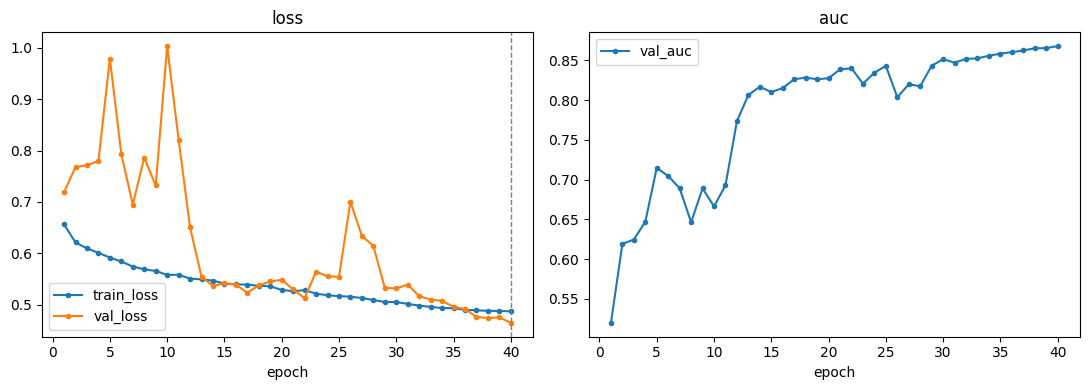

In [6]:
V.plot_training_curves(history).savefig(dirs["figures"] / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 6 - In-distribution evaluation (ai-real-images test)

Load the **EMA** weights from the best checkpoint, score test, report metrics at 0.5 and at a val-tuned threshold, save figures.

tuned threshold (on val): 0.5312


,threshold,n,n_fake,n_real,accuracy,f1_macro,precision,recall,auc_roc,pr_auc,mcc,brier
0,0.5,11963,5977,5986,0.786843,0.786406,0.762525,0.832692,0.867183,0.856252,0.576155,0.150522


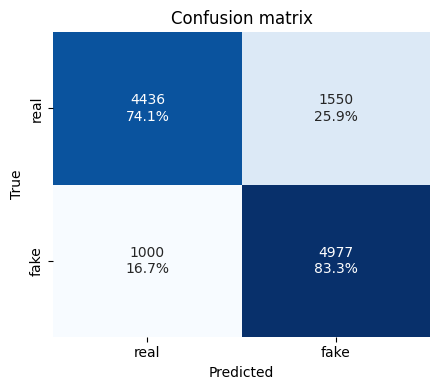

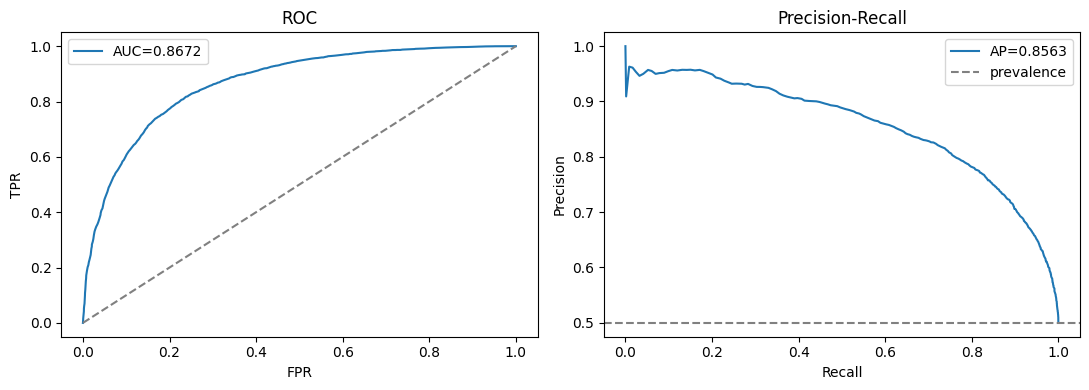

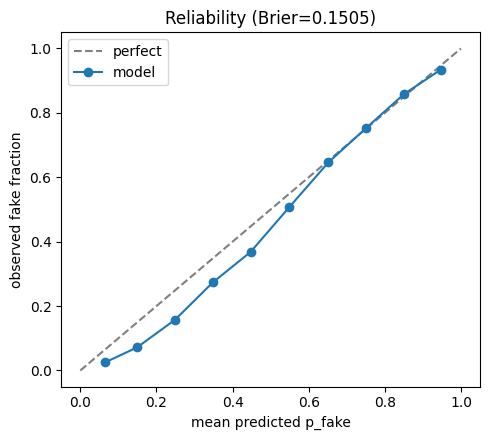

In [7]:
T.load_ema_weights(dirs["models"] / "best.pt", model, map_location=device)
yt, pt, _ = T.evaluate(model, test_loader, device)
yv, pv, _ = T.evaluate(model, val_loader, device)
tuned = Me.best_f1_threshold(yv, pv)
m05 = Me.classification_metrics(yt, pt, threshold=0.5)
mtuned = Me.classification_metrics(yt, pt, threshold=tuned["threshold"])
print("tuned threshold (on val):", round(tuned["threshold"], 4))
display(Me.summary_table(m05))

V.plot_confusion(m05["confusion_matrix"]).savefig(dirs["figures"] / "confusion.png", dpi=150, bbox_inches="tight")
V.plot_roc_pr(yt, pt).savefig(dirs["figures"] / "roc_pr.png", dpi=150, bbox_inches="tight")
V.plot_reliability(yt, pt).savefig(dirs["figures"] / "reliability.png", dpi=150, bbox_inches="tight")
plt.show()

## 7 - Cross-generator (OOD) preview — tiny-genimage

Same size/normalization as training; per-generator accuracy on data the model never saw.

,generator,accuracy,n
0,adm,0.487800,5000
1,biggan,0.412200,5000
2,glide,0.585800,5000
3,midjourney,0.572715,4999
4,sdv5,0.546309,4999
5,vqdm,0.430600,5000
6,wukong,0.597400,5000


overall OOD accuracy: 0.5190  (in-dist test acc: 0.7868)


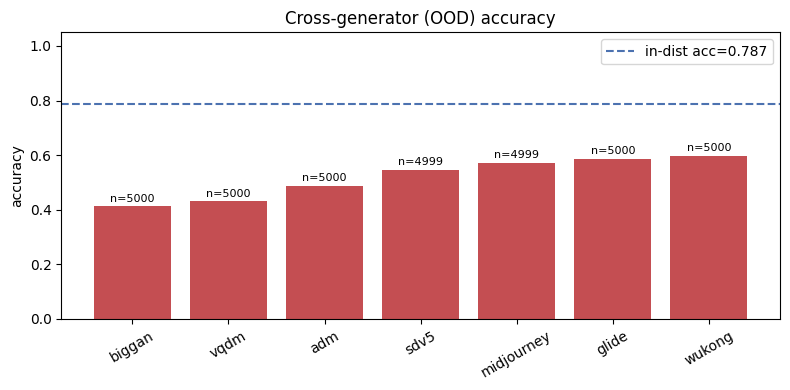

In [8]:
GEN_MAP = {
    "imagenet_ai_0419_biggan": "biggan", "imagenet_ai_0419_vqdm": "vqdm",
    "imagenet_ai_0424_sdv5": "sdv5", "imagenet_ai_0424_wukong": "wukong",
    "imagenet_ai_0508_adm": "adm", "imagenet_glide": "glide", "imagenet_midjourney": "midjourney",
}
ood_loader, ood_df = D.make_ood_loader(TINY_MANIFEST, WORKING_SIZE, BATCH_SIZE, mean, std, num_workers=NUM_WORKERS)
yo, po, _ = T.evaluate(model, ood_loader, device)
ood_df = ood_df.assign(p_fake=po, y_true=yo)
ood_df["y_pred"] = (ood_df["p_fake"] >= 0.5).astype(int)
ood_df["generator"] = ood_df["source"].map(GEN_MAP).fillna(ood_df["source"])
rows = [{"generator": gen, "accuracy": float((g["y_pred"] == g["y_true"]).mean()), "n": int(len(g))}
        for gen, g in ood_df.groupby("generator")]
per_gen = pd.DataFrame(rows)
overall_ood = float((ood_df["y_pred"] == ood_df["y_true"]).mean())
display(per_gen)
print(f"overall OOD accuracy: {overall_ood:.4f}  (in-dist test acc: {m05['accuracy']:.4f})")
V.plot_per_generator_bar(per_gen, ref_acc=m05["accuracy"]).savefig(dirs["figures"] / "ood_per_generator.png", dpi=150, bbox_inches="tight")
plt.show()

## 8 - Explainability (Grad-CAM)

Target layer = the last residual block (before SE/GAP).

C:\Users\user\AppData\Local\Temp\ipykernel_14192\3834542690.py:8: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_numpy.cpp:212.)
  xt = eval_tf(torch.from_numpy(arr).permute(2, 0, 1))


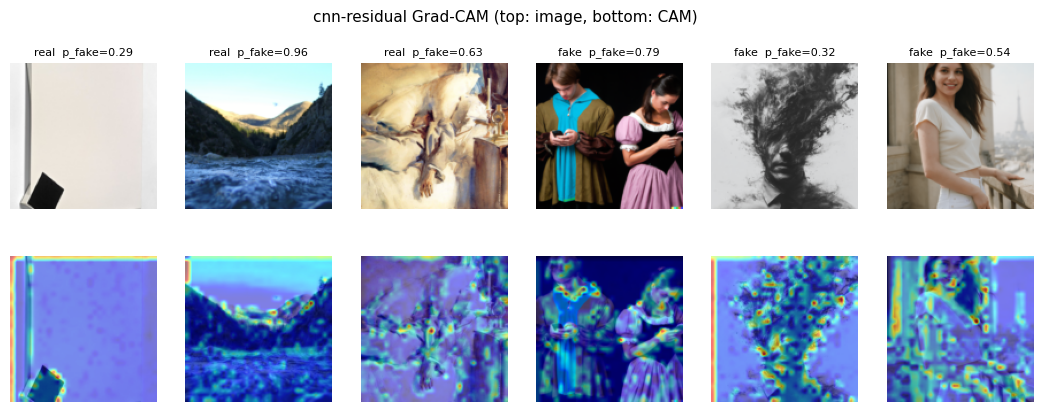

In [9]:
eval_tf = D.build_eval_tf(WORKING_SIZE, mean, std)
target_layers = [model.stages[-1]]
examples = E.pick_examples(test_df, n_per_class=3, seed=0)
fig, axes = plt.subplots(2, len(examples), figsize=(2.2 * len(examples), 4.6))
model.eval()
for j, ex in enumerate(examples):
    arr = eda.read_rgb(ex["filepath"])
    xt = eval_tf(torch.from_numpy(arr).permute(2, 0, 1))
    x = xt.unsqueeze(0).to(device)
    rgb = D.denormalize(xt, mean, std).permute(1, 2, 0).numpy()
    with torch.no_grad():
        p = torch.sigmoid(model(x)).item()
    overlay = E.gradcam_overlay(model, target_layers, x, rgb)
    axes[0, j].imshow(rgb); axes[0, j].axis("off"); axes[0, j].set_title(f"{ex['label']}  p_fake={p:.2f}", fontsize=8)
    axes[1, j].imshow(overlay); axes[1, j].axis("off")
fig.suptitle("cnn-residual Grad-CAM (top: image, bottom: CAM)", fontsize=11)
fig.savefig(dirs["figures"] / "gradcam.png", dpi=150, bbox_inches="tight")
plt.show()

## 9 - Save metrics.json

In [10]:
record = {
    "pipeline": PIPELINE,
    "created": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "working_size": WORKING_SIZE,
    "normalization": NORM,
    "dataset": {"in_distribution": "ai-real-images", "ood": "tiny-genimage"},
    "threshold_default": 0.5,
    "threshold_tuned": tuned["threshold"],
    "in_distribution": {"at_0.5": m05, "at_tuned": mtuned},
    "ood": {
        "overall_accuracy": overall_ood,
        "per_generator": {r.generator: {"accuracy": r.accuracy, "n": r.n} for r in per_gen.itertuples()},
        "preview": True,
    },
    "train_history": {
        "epochs": len(history["val_auc"]),
        "best_epoch": int(np.argmax(history["val_auc"])) + 1,
        "best_val_auc": float(max(history["val_auc"])),
    },
    "figures": {k: f"figures/{k}.png" for k in ["training_curves", "confusion", "roc_pr", "reliability", "ood_per_generator", "gradcam"]},
}
Me.save_metrics(record, dirs["metrics"] / "metrics.json")
print("saved", dirs["metrics"] / "metrics.json")
print("\nin-dist @0.5:  acc {accuracy:.4f}  f1 {f1_macro:.4f}  auc {auc_roc:.4f}  mcc {mcc:.4f}  brier {brier:.4f}".format(**m05))

saved C:\Users\user\Desktop\MSc - AI\Εξάμηνο 2ο\Βαθιά Μάθηση\deepfake-detection\notebooks\artifacts\cnn-residual\metrics\metrics.json

in-dist @0.5:  acc 0.7868  f1 0.7864  auc 0.8672  mcc 0.5762  brier 0.1505


**Next:** `06_cnn-finetune.ipynb` (two-stage fine-tuning of ResNet50 + EfficientNet-B0).